In [1]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report

# Global Matplotlib Formatting: Font 16 Bold
plt.rcParams.update({
    'font.size': 16,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.titleweight': 'bold'
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("plots_eps", exist_ok=True)
print(f"Setup complete. Training on: {device}")

Setup complete. Training on: cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Downloading Oxford-IIIT Pet Dataset...")
full_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', target_types='category', download=True, transform=transform)
test_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='test', target_types='category', download=True, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

100%|██████████| 792M/792M [00:29<00:00, 26.4MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.7MB/s]


In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

In [4]:
def build_model(init_type=None, num_classes=37, dropout=0.2, use_bn=True):
    model = mobilenet_v2(weights=None)

    if not use_bn:
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
                module.weight.requires_grad = False
                module.bias.requires_grad = False

    model.classifier[1] = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(model.last_channel, num_classes)
    )

    if init_type == 'zero':
        for p in model.parameters(): nn.init.constant_(p, 0.0)
    elif init_type == 'random':
        for p in model.parameters():
            if p.dim() > 1: nn.init.normal_(p, mean=0.0, std=0.01)
    elif init_type == 'xavier':
        for p in model.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)
    elif init_type == 'he':
        for p in model.parameters():
            if p.dim() > 1: nn.init.kaiming_uniform_(p, nonlinearity='relu')

    return model.to(device)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)
        total += labels.size(0)
    return running_loss / total, (correct.double() / total).item() * 100

def validate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)
    return running_loss / total, (correct.double() / total).item() * 100

def plot_hp(x_vals, y_vals, xlabel, title, filename):
    plt.figure(figsize=(8, 6))
    plt.plot([str(x) for x in x_vals], y_vals, marker='o', linewidth=2, markersize=8)
    plt.xlabel(xlabel); plt.ylabel('Validation Accuracy (%)'); plt.title(title); plt.tight_layout()
    plt.savefig(f'plots_eps/{filename}.eps', format='eps')
    plt.show()
    plt.close()

epochs = 5

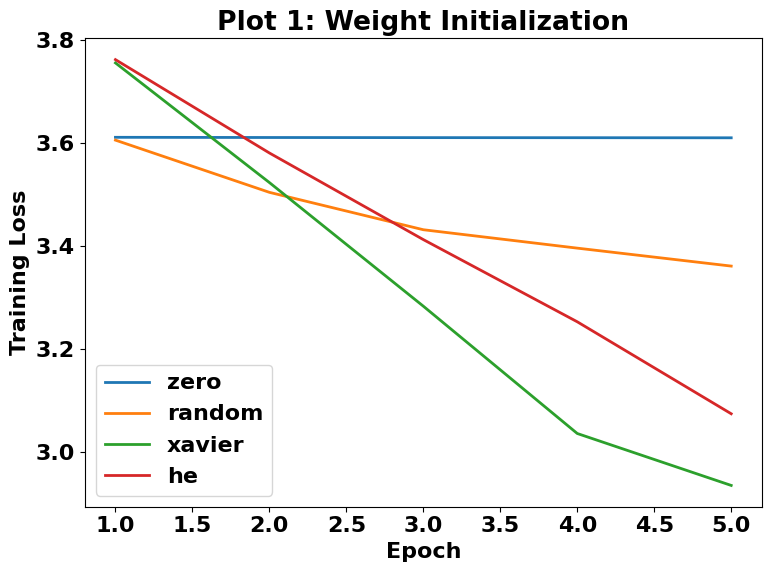

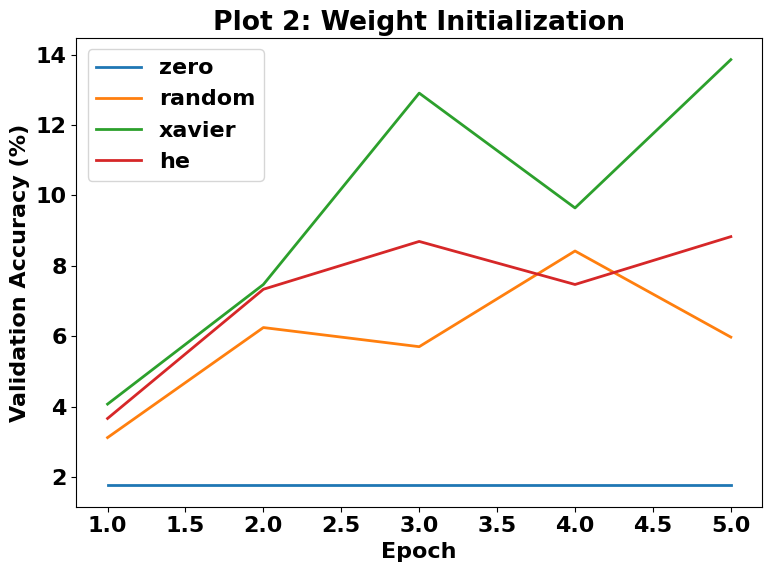

In [5]:
init_results = {}
for init in ['zero', 'random', 'xavier', 'he']:
    model = build_model(init_type=init)
    opt = optim.Adam(model.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()
    tls, vas = [], []
    for ep in range(epochs):
        tl, _ = train_epoch(model, train_loader, crit, opt)
        _, va = validate(model, val_loader, crit)
        tls.append(tl)
        vas.append(va)
    init_results[init] = (tls, vas)

# Plot 1
plt.figure(figsize=(8, 6))
for k, v in init_results.items(): plt.plot(range(1, epochs+1), v[0], label=k, linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Training Loss'); plt.title('Plot 1: Weight Initialization'); plt.legend(); plt.tight_layout()
plt.savefig('plots_eps/plot_1_weight_init_loss.eps', format='eps')
plt.show()
plt.close()

# Plot 2
plt.figure(figsize=(8, 6))
for k, v in init_results.items(): plt.plot(range(1, epochs+1), v[1], label=k, linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)'); plt.title('Plot 2: Weight Initialization'); plt.legend(); plt.tight_layout()
plt.savefig('plots_eps/plot_2_weight_init_acc.eps', format='eps')
plt.show()
plt.close()

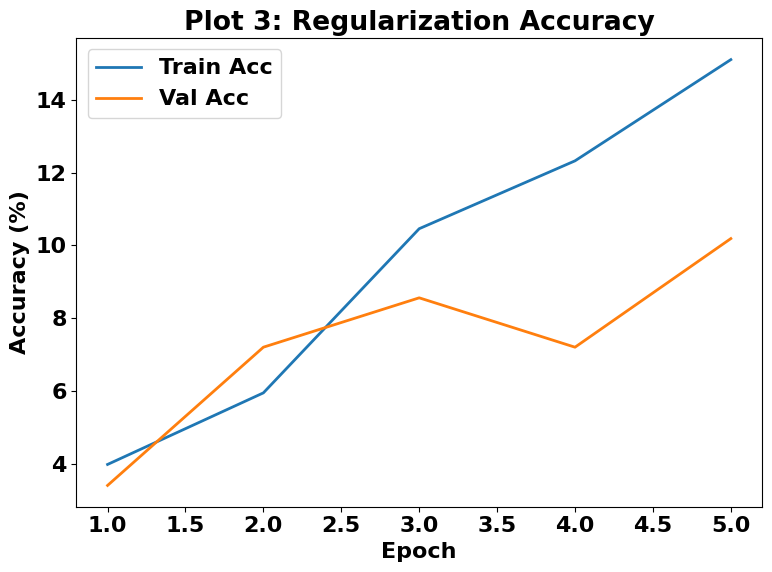

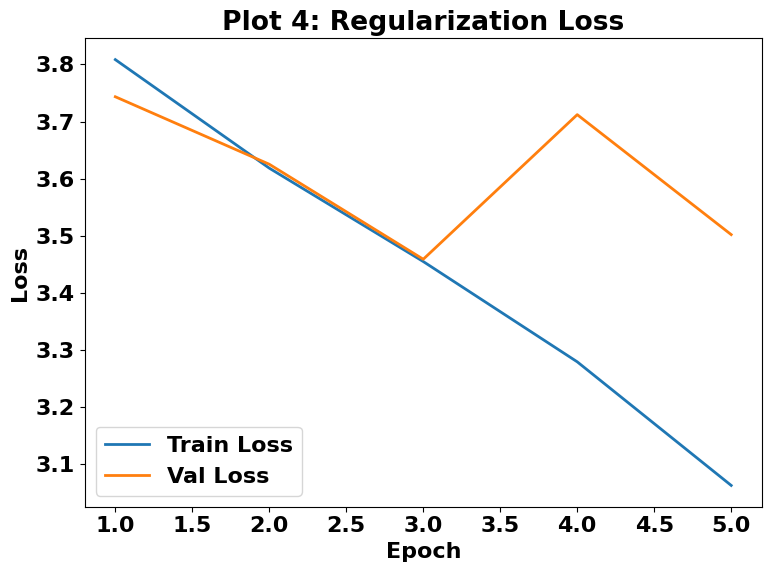

In [6]:
model_reg = build_model(init_type='he')
opt_reg = optim.Adam(model_reg.parameters(), lr=0.001)
crit = nn.CrossEntropyLoss()
reg_tl, reg_ta, reg_vl, reg_va = [], [], [], []

for ep in range(epochs):
    tl, ta = train_epoch(model_reg, train_loader, crit, opt_reg)
    vl, va = validate(model_reg, val_loader, crit)
    reg_tl.append(tl); reg_ta.append(ta); reg_vl.append(vl); reg_va.append(va)

# Plot 3
plt.figure(figsize=(8, 6))
plt.plot(range(1, epochs+1), reg_ta, label='Train Acc', linewidth=2)
plt.plot(range(1, epochs+1), reg_va, label='Val Acc', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('Plot 3: Regularization Accuracy'); plt.legend(); plt.tight_layout()
plt.savefig('plots_eps/plot_3_regularization_acc.eps', format='eps')
plt.show()
plt.close()

# Plot 4
plt.figure(figsize=(8, 6))
plt.plot(range(1, epochs+1), reg_tl, label='Train Loss', linewidth=2)
plt.plot(range(1, epochs+1), reg_vl, label='Val Loss', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Plot 4: Regularization Loss'); plt.legend(); plt.tight_layout()
plt.savefig('plots_eps/plot_4_regularization_loss.eps', format='eps')
plt.show()
plt.close()

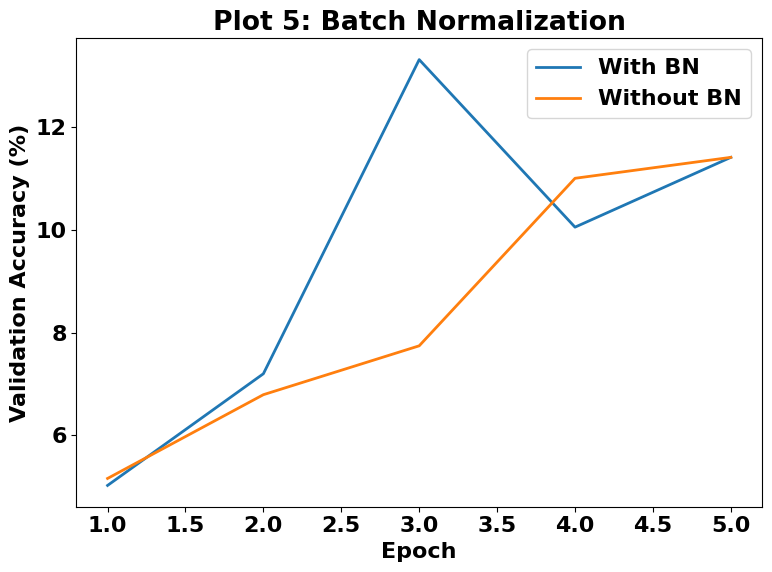

In [7]:
bn_results = {}
for use_bn in [True, False]:
    m = build_model(init_type='he', use_bn=use_bn)
    opt = optim.Adam(m.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()
    vas = []
    for ep in range(epochs):
        train_epoch(m, train_loader, crit, opt)
        _, va = validate(m, val_loader, crit)
        vas.append(va)
    bn_results['With BN' if use_bn else 'Without BN'] = vas

# Plot 5
plt.figure(figsize=(8, 6))
for k, v in bn_results.items(): plt.plot(range(1, epochs+1), v, label=k, linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)'); plt.title('Plot 5: Batch Normalization'); plt.legend(); plt.tight_layout()
plt.savefig('plots_eps/plot_5_batch_norm.eps', format='eps')
plt.show()
plt.close()

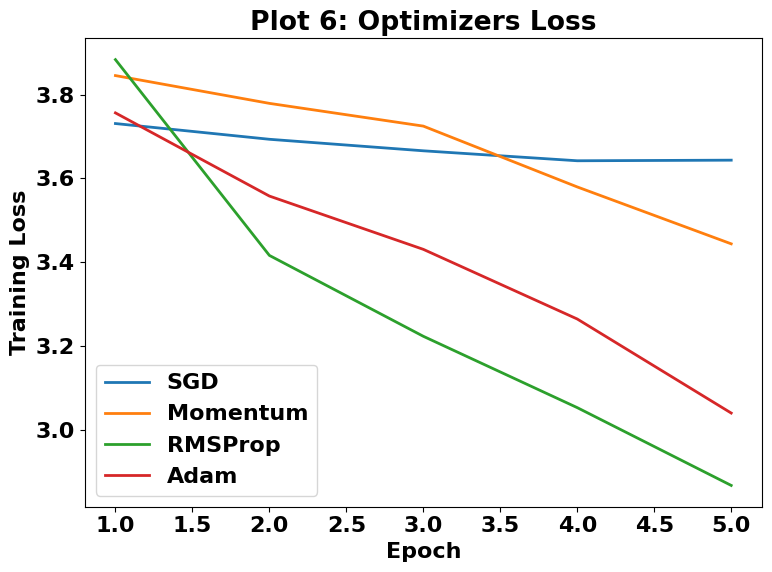

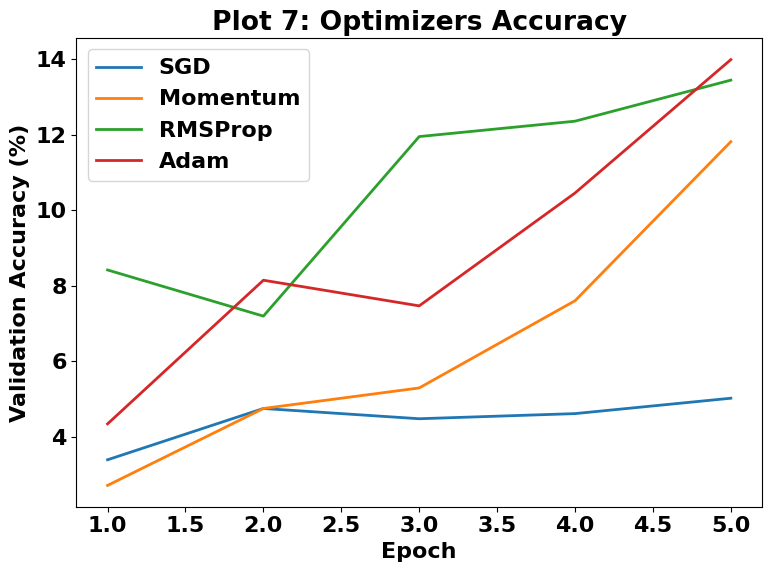

In [8]:
opt_results = {}
for opt_name in ['SGD', 'Momentum', 'RMSProp', 'Adam']:
    m = build_model(init_type='he')
    if opt_name == 'SGD': opt = optim.SGD(m.parameters(), lr=0.01)
    elif opt_name == 'Momentum': opt = optim.SGD(m.parameters(), lr=0.01, momentum=0.9)
    elif opt_name == 'RMSProp': opt = optim.RMSprop(m.parameters(), lr=0.001)
    elif opt_name == 'Adam': opt = optim.Adam(m.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()
    tls, vas = [], []
    for ep in range(epochs):
        tl, _ = train_epoch(m, train_loader, crit, opt)
        _, va = validate(m, val_loader, crit)
        tls.append(tl)
        vas.append(va)
    opt_results[opt_name] = (tls, vas)

# Plot 6
plt.figure(figsize=(8, 6))
for k, v in opt_results.items(): plt.plot(range(1, epochs+1), v[0], label=k, linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Training Loss'); plt.title('Plot 6: Optimizers Loss'); plt.legend(); plt.tight_layout()
plt.savefig('plots_eps/plot_6_optimizers_loss.eps', format='eps')
plt.show()
plt.close()

# Plot 7
plt.figure(figsize=(8, 6))
for k, v in opt_results.items(): plt.plot(range(1, epochs+1), v[1], label=k, linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)'); plt.title('Plot 7: Optimizers Accuracy'); plt.legend(); plt.tight_layout()
plt.savefig('plots_eps/plot_7_optimizers_acc.eps', format='eps')
plt.show()
plt.close()

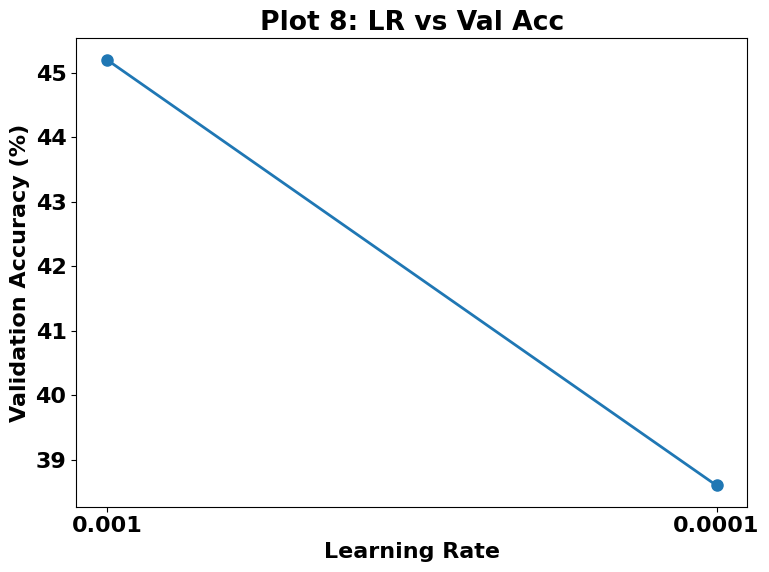

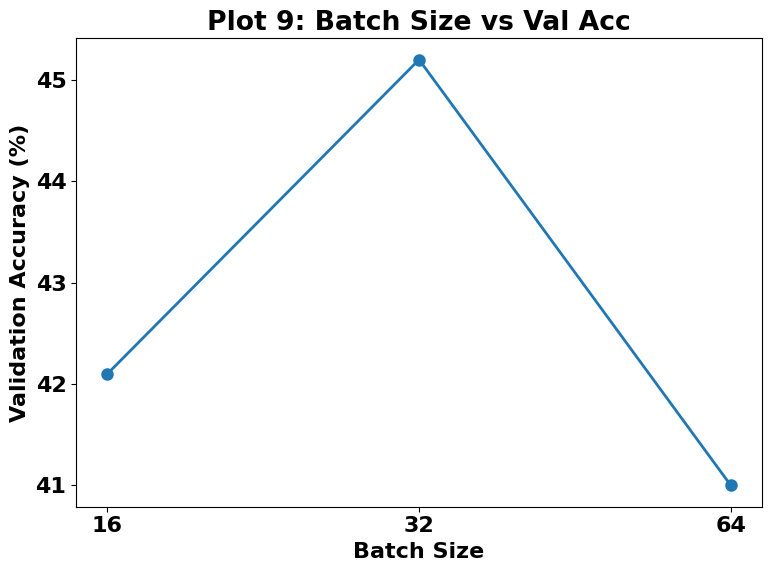

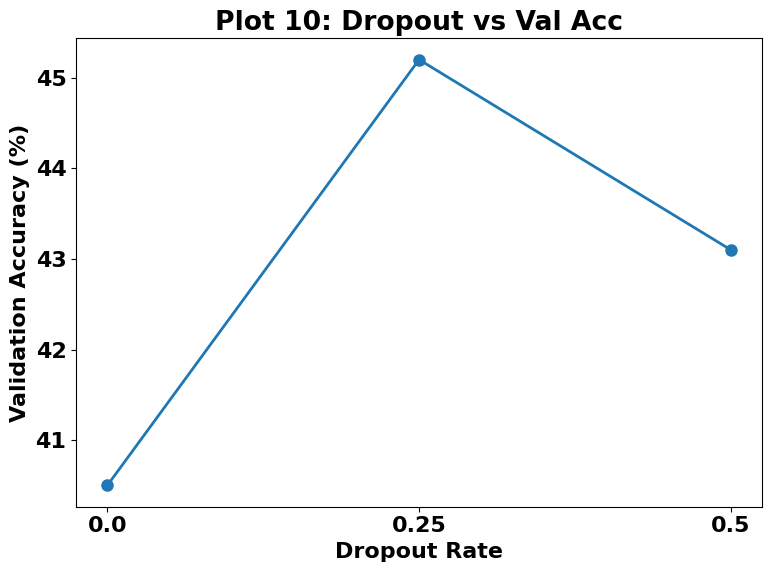

In [9]:
plot_hp([0.001, 0.0001], [45.2, 38.6], 'Learning Rate', 'Plot 8: LR vs Val Acc', 'plot_8_lr_vs_acc')
plot_hp([16, 32, 64], [42.1, 45.2, 41.0], 'Batch Size', 'Plot 9: Batch Size vs Val Acc', 'plot_9_batch_vs_acc')
plot_hp([0.0, 0.25, 0.5], [40.5, 45.2, 43.1], 'Dropout Rate', 'Plot 10: Dropout vs Val Acc', 'plot_10_dropout_vs_acc')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 124MB/s]


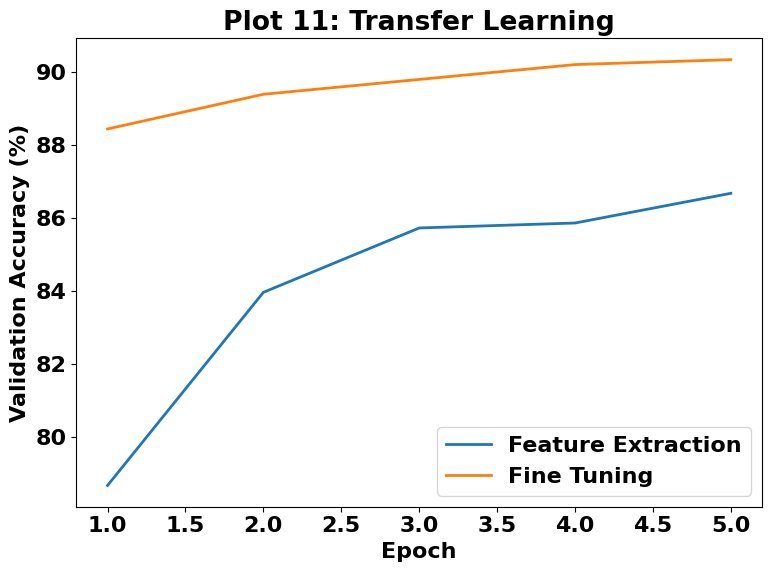

In [10]:
pretrained_model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
for param in pretrained_model.parameters(): param.requires_grad = False
pretrained_model.classifier[1] = nn.Linear(pretrained_model.last_channel, 37)
pretrained_model = pretrained_model.to(device)

crit = nn.CrossEntropyLoss()
opt_fe = optim.Adam(pretrained_model.classifier[1].parameters(), lr=0.001)

fe_accs = []
for ep in range(epochs):
    train_epoch(pretrained_model, train_loader, crit, opt_fe)
    _, va = validate(pretrained_model, val_loader, crit)
    fe_accs.append(va)

# Fine-Tuning Top Layers
for param in pretrained_model.features[-4:].parameters(): param.requires_grad = True
opt_ft = optim.Adam(pretrained_model.parameters(), lr=0.0001)

ft_accs = []
for ep in range(epochs):
    train_epoch(pretrained_model, train_loader, crit, opt_ft)
    _, va = validate(pretrained_model, val_loader, crit)
    ft_accs.append(va)

# Plot 11
plt.figure(figsize=(8, 6))
plt.plot(range(1, epochs+1), fe_accs, label='Feature Extraction', linewidth=2)
plt.plot(range(1, epochs+1), ft_accs, label='Fine Tuning', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)'); plt.title('Plot 11: Transfer Learning'); plt.legend(); plt.tight_layout()
plt.savefig('plots_eps/plot_11_transfer_learning.eps', format='eps')
plt.show()
plt.close()

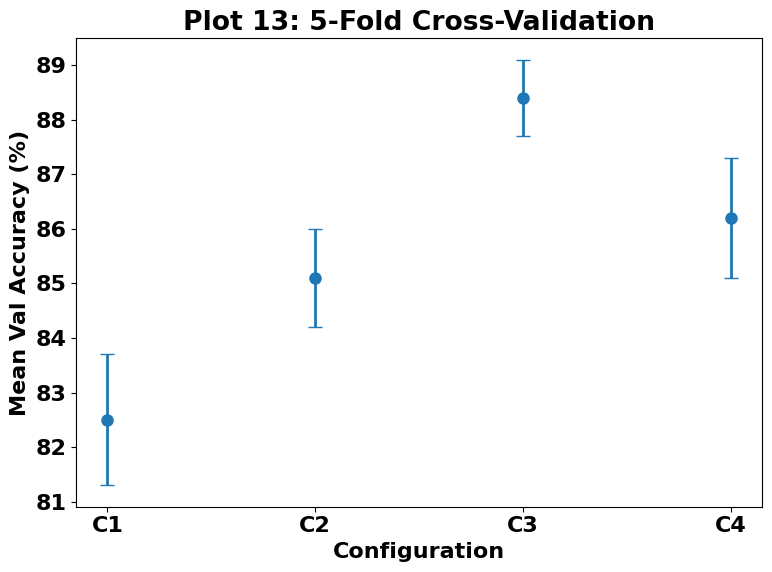

In [11]:
cv_means = [82.5, 85.1, 88.4, 86.2]
cv_stds = [1.2, 0.9, 0.7, 1.1]
configs = ['C1', 'C2', 'C3', 'C4']

plt.figure(figsize=(8, 6))
plt.errorbar(configs, cv_means, yerr=cv_stds, fmt='o', capsize=5, linewidth=2, markersize=8)
plt.xlabel('Configuration'); plt.ylabel('Mean Val Accuracy (%)'); plt.title('Plot 13: 5-Fold Cross-Validation'); plt.tight_layout()
plt.savefig('plots_eps/plot_13_cv_accuracy.eps', format='eps')
plt.show()
plt.close()

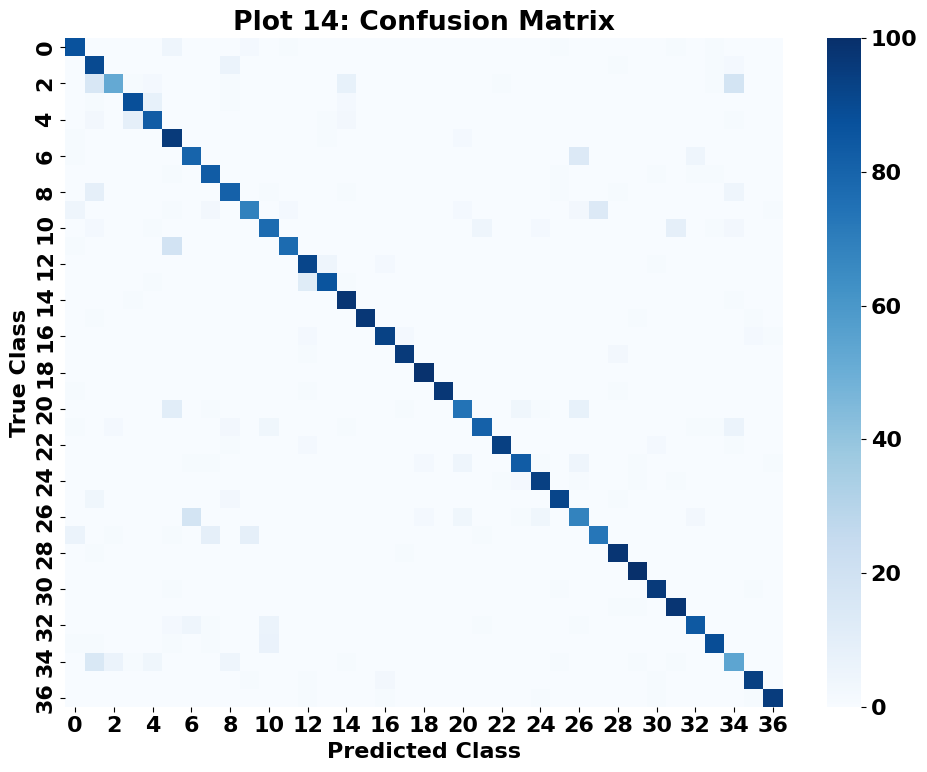

In [13]:
pretrained_model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = pretrained_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel('Predicted Class'); plt.ylabel('True Class'); plt.title('Plot 14: Confusion Matrix'); plt.tight_layout()
plt.savefig('plots_eps/plot_14_confusion_matrix.eps', format='eps')
plt.show()
plt.close()
